# Manejo de datos con Pandas
____
__Juan Camilo Murcia Pérez 2191322 Grupo PA2__

>_Las ciencias aplicadas no existen, sólo las aplicaciones de la ciencia_. 

                                                  Louis Pasteur

### Nota importante:
Hola profesor, espero que esté bien, quisiera pedirle un favor importante para mi en estos momentos: al iniciar este curso de Intro a las Herramientas mi poco conocimiento de programación me condenó en el primer corte y la nota salió nefasta, en el segundo me recuperé bastante pero aun así no logré todo lo que se pedía, este lo trabajé de la mejor manera que pude pero necesito sacar una buena calificación para no tener que repetir está asignatura, ya uq me encuentro bastante atrasado en mi avance del plan de estudios por problemas que tuve en los primeros semestres (por tiempo soy de 5to pero en asignaturas 3ro-4to). Espero que esto no lo incomode, gracias por las clases de pandas, esas siI me sirvieron un montón. 

## Paso 1 y 2:

Primeramente importamos las librerías necesarias sugeridas para la actividad, el trabajo de este paso es unir los diferentes archivos en un solo Dataframe:

In [1]:
import numpy as np
import pandas as pd #librería principal para el manejo de datos
from scipy.optimize import curve_fit #para el ajuste de curvas del inciso 4 del trabajo
import matplotlib.pyplot as plt # Agrega una temática a las gráficas
plt.style.use("seaborn") #usamos el estilo Seaborn

Le agregamos la línea final de header=[0] para asegurarnos que uso la primer línea como código, el delimiter=";" no es necesario

In [2]:
Global_active_power=pd.read_csv("Tarea IHC/Global_active_power.csv", header=[0])
Global_intensity=pd.read_csv("Tarea IHC/Global_intensity.csv", header=[0])
Global_reactive_power=pd.read_csv("Tarea IHC/Global_reactive_power.csv", header=[0])
Voltaje=pd.read_csv("Tarea IHC/Voltage.csv", header=[0])

Renombramos los Dataframes para facilitar la lectura y escritura del código

In [3]:
GAP=Global_active_power
GI=Global_intensity
GRP=Global_reactive_power
Vt=Voltaje

__Nota:__ No sé si es mi computador pero no me deja unir más de dos _Dataframes_ a la vez, entonces tuve que iterar este punto, para unirlos usamos la función de pandas pd.merge() y el argumento on="Datetime" se refiere a la columna con respecto aa la cual estaremos organizando las otras columnas.

In [4]:
data=pd.merge(GAP,GI,on="Datetime")

Repetimos para GRP:

In [5]:
data=pd.merge(data,GRP,on="Datetime")

Repetiremos lo mismo Vt:

In [6]:
data=pd.merge(data,Vt,on="Datetime")

Eliminamos las filas donde __al menos__ falte un dato con dp.dropna()

In [7]:
data=data.dropna()

### Ahora procedemos a reorganizar los datos de "data"

# Paso 3
Vamos a "resamplear" la frecuencia con la que se organizan los datos, para ello usamos la función pd.resample() para las frecuencias de día= "D" y mes= "M". Al momento de hacer este resampleo me saltaba siempre que no existia formato "Datetimeindex" para la columna "Datetime" en _data_, entonces le doy formato con la siguiente función:

In [8]:
data=data.set_index(pd.DatetimeIndex(data['Datetime']))

Eliminamos la columna "Datetime" que no tiene el formato necesario:

In [9]:
del(data["Datetime"])

Introduciremos las columnas correspondientes a $GRP(1000/60)$ y $GAP(1000/60)$

In [10]:
data["GAP 1000/60"]=data["Global_active_power"]*1000/60
data["GRP 1000/60"]=data["Global_reactive_power"]*1000/60

Ahora cambiaremos la frecuencia de muestreo para las filas a días y a meses:

In [11]:
data_día=data.resample('D').mean()
data_mes=data.resample('M').mean()

Finalmente visualizaremos como quedó el arreglo de nuestros datos:

In [12]:
data

,Global_active_power,Global_intensity,Global_reactive_power,Voltage,GAP 1000/60,GRP 1000/60
Datetime,,,,,,
2010-01-01 00:00:00,1.790,7.4,0.236,240.65,29.833333,3.933333
2010-01-01 00:01:00,1.780,7.4,0.234,240.07,29.666667,3.900000
2010-01-01 00:02:00,1.780,7.4,0.234,240.15,29.666667,3.900000
2010-01-01 00:03:00,1.746,7.2,0.186,240.26,29.100000,3.100000
2010-01-01 00:04:00,1.686,7.0,0.102,240.12,28.100000,1.700000
...,...,...,...,...,...,...
2010-11-26 20:58:00,0.946,4.0,0.000,240.43,15.766667,0.000000
2010-11-26 20:59:00,0.944,4.0,0.000,240.00,15.733333,0.000000
2010-11-26 21:00:00,0.938,3.8,0.000,239.82,15.633333,0.000000


## Paso 4:

Momento de hacer el análisis gráfico de distintas regresiones lineales para los datos y determinar de qué manera es mejor manejarlos, para esto usaremos el la librería **scipy.optimize** y el módulo __curve_fit__:

### Regresión por minutos
observaremos si existe alguna relación entre _"Global Active Power" vs "Global Intensity"_ o _"Global Active Power vs Voltaje"_, también hacemos esto para las columnas GAP 1000/60

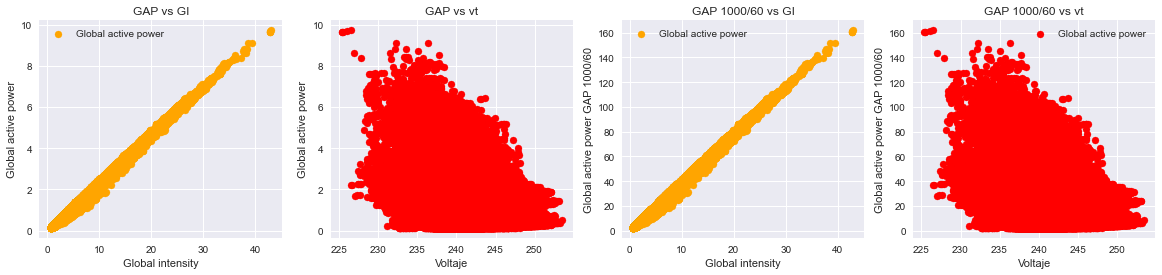

In [15]:
plt.figure(figsize=(20,4)) #el par (16,16) da las proporciones la imagen

plt.subplot(1,4,1)# esto es =(# de filas, # columnas, posición del elemento dentro del arreglo desde 1 hasta #f*#c)
plt.scatter(data['Global_intensity'],data['Global_active_power'], color="orange", label='Global active power')

plt.xlabel('Global intensity')                  
plt.ylabel('Global active power')
plt.title('GAP vs GI')
plt.legend(loc='upper left', frameon=False)

plt.subplot(1,4,2)
plt.scatter(data['Voltage'],data['Global_active_power'], color="red", label='Global active power')


plt.xlabel('Voltaje')                  
plt.ylabel('Global active power')
plt.title('GAP vs vt')

plt.subplot(1,4,3)
plt.scatter(data['Global_intensity'],data['GAP 1000/60'], color="orange", label='Global active power')

plt.xlabel('Global intensity')                  
plt.ylabel('Global active power GAP 1000/60')
plt.title('GAP 1000/60 vs GI')
plt.legend(loc='upper left', frameon=False)

plt.subplot(1,4,4)
plt.scatter(data['Voltage'],data['GAP 1000/60'], color="red", label='Global active power')


plt.xlabel('Voltaje')                  
plt.ylabel('Global active power GAP 1000/60')
plt.title('GAP 1000/60 vs vt')

plt.legend(loc='upper right', frameon=False)
plt.show()

De las gráficas de arriba podemos ver que solo el arreglo de _"Global active power vs Global intensity"_ tienen una relacón evidente, puede ser porque hay muchos datos y en las demás no se solgra ver con claridad, trabajaremos ahora con menos datos usando la función de abajo donde se seleccionarán al azar diferentes valores de data y luego se reducirá el conjunto a un 1% de la totalidad:

In [17]:
p=np.random.random(len(data))
kk=p<0.01

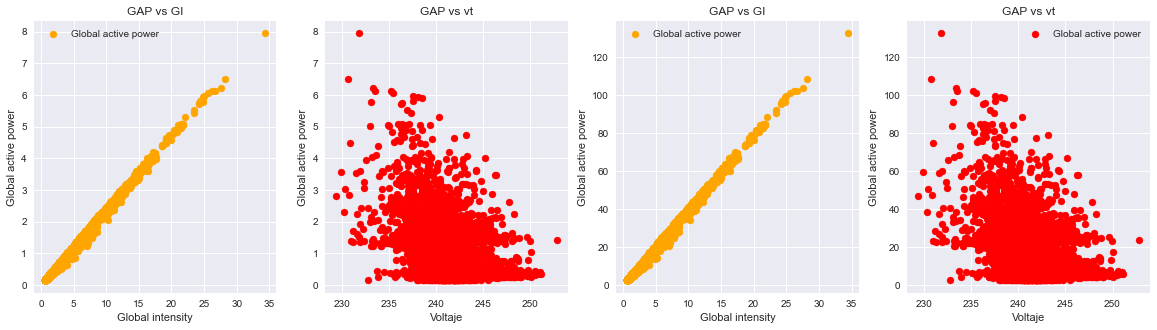

In [18]:
plt.figure(figsize=(20,5)) #el par (16,5) da las proporciones la imagen

plt.subplot(1,4,1)# esto es =(# de filas, # columnas, posición del elemento dentro del arreglo desde 1 hasta #f*#c)
plt.scatter(data['Global_intensity'][kk],data['Global_active_power'][kk], color="orange", label='Global active power')

plt.xlabel('Global intensity')                  
plt.ylabel('Global active power')
plt.title('GAP vs GI')
plt.legend(loc='upper left', frameon=False)

plt.subplot(1,4,2)
plt.scatter(data['Voltage'][kk],data['Global_active_power'][kk], color="red", label='Global active power')


plt.xlabel('Voltaje')                  
plt.ylabel('Global active power')
plt.title('GAP vs vt')

plt.subplot(1,4,3)# esto es =(# de filas, # columnas, posición del elemento dentro del arreglo desde 1 hasta #f*#c)
plt.scatter(data['Global_intensity'][kk],data['GAP 1000/60'][kk], color="orange", label='Global active power')

plt.xlabel('Global intensity')                  
plt.ylabel('Global active power')
plt.title('GAP vs GI')
plt.legend(loc='upper left', frameon=False)

plt.subplot(1,4,4)
plt.scatter(data['Voltage'][kk],data['GAP 1000/60'][kk], color="red", label='Global active power')


plt.xlabel('Voltaje')                  
plt.ylabel('Global active power')
plt.title('GAP vs vt')

plt.legend(loc='upper right', frameon=False)
plt.show()

De la gráfica de arriba vemos que además de _"Global Active Power" vs "Global Intensity"_ las otras también presentan cierta relación, pero para los objetivos de nuestro estudio nos quedaremos con las relaciones lineales de, es decir, con las primera gráfica.

Graficaremos ahora los diferentes arreglos con distintas frecuencias:

## Gráficas en frecuencia de minutos, días, meses

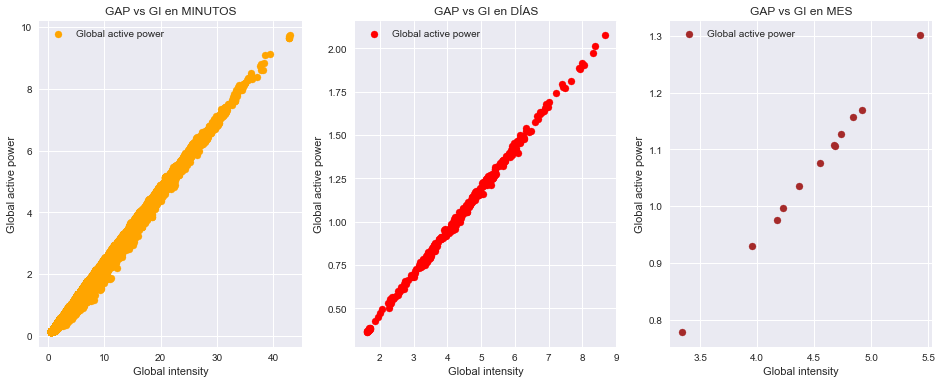

In [19]:
plt.figure(figsize=(16,6)) 
plt.subplot(1,3,1)
plt.scatter(data['Global_intensity'],data['Global_active_power'], color="orange", label='Global active power')

plt.xlabel('Global intensity')                  
plt.ylabel('Global active power')
plt.title('GAP vs GI en MINUTOS')
plt.legend(loc='upper left', frameon=False)

plt.subplot(1,3,2)
plt.scatter(data_día['Global_intensity'],data_día['Global_active_power'], color="red", label='Global active power')

plt.xlabel('Global intensity')                  
plt.ylabel('Global active power')
plt.title('GAP vs GI en DÍAS')
plt.legend(loc='upper left', frameon=False)

plt.subplot(1,3,3)
plt.scatter(data_mes['Global_intensity'],data_mes['Global_active_power'], color="brown", label='Global active power')

plt.xlabel('Global intensity')                  
plt.ylabel('Global active power')
plt.title('GAP vs GI en MES')
plt.legend(loc='upper left', frameon=False)

plt.show()

Tomamos el codigo que se creó en clase para hallar los coeficientes de la curva y también tomaremos la función de medición del error.

In [20]:
def G(x,a,b):
    return a*x+b #Este será para la relación Global_active_power = a(Global_intensity)+b
def H(x,x1,a,b,c):
    return a*x+b*x1+c #define la relación Global_active_power = a(Global_intensity)+b(Voltage)+c

In [21]:
def get_fit(G,xdata,ydata,labelx,labely,r): #define los argumentos variables
    popt, pcov = curve_fit(G, xdata, ydata) #datos a analizar con curve_fit para los coeficientes y su covarianza 
    popt, pcov = np.around(popt,r), np.around(np.sqrt(np.diag(pcov)),r)
    x=np.linspace(xdata.min(),xdata.max(),100) #datos continuos para la curva creada 
    plt.figure(figsize=(8,6)) 
    plt.plot(x, G(x, *popt), 'r-',color="orange",label=r'fit: {}$\pm${}'.format(np.around(tuple(popt),r),tuple(pcov)))
    plt.scatter(xdata,ydata,color="purple",label="Original data")
    plt.xlabel(labelx)
    plt.ylabel(labely)
    plt.legend()
    plt.show()
    print("Los Coeficientes son : {}".format(popt))
    print("Sigma_Coeficients son : {}".format(pcov))
    return #popt, np.sqrt(np.diag(pcov))

### Calculamos para datos en minutos:

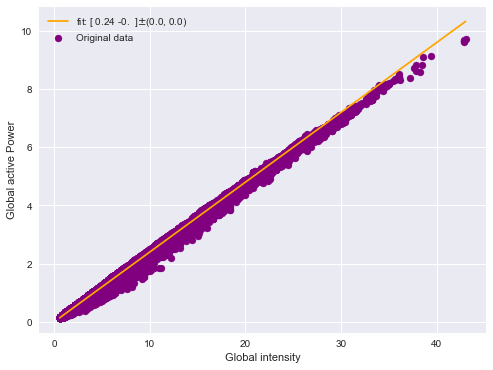

Los Coeficientes son : [ 0.24 -0.  ]
Sigma_Coeficients son : [0. 0.]


In [22]:
get_fit(G,data['Global_intensity'],data['Global_active_power'], "Global intensity", "Global active Power", 2)

### Calculamos para datos en días:

In [24]:
data_día=data_día.dropna()

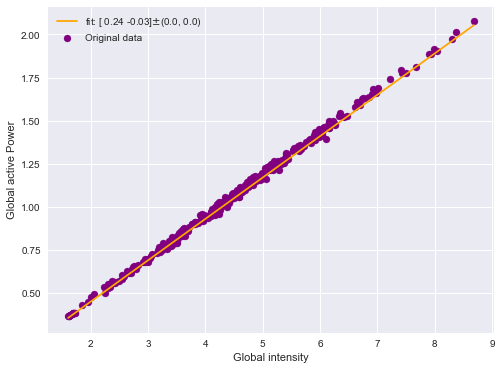

Los Coeficientes son : [ 0.24 -0.03]
Sigma_Coeficients son : [0. 0.]


In [25]:
get_fit(G,data_día['Global_intensity'],data_día['Global_active_power'], "Global intensity", "Global active Power", 2)

### Cálculo para datos con meses

In [26]:
data_mes=data_mes.dropna()

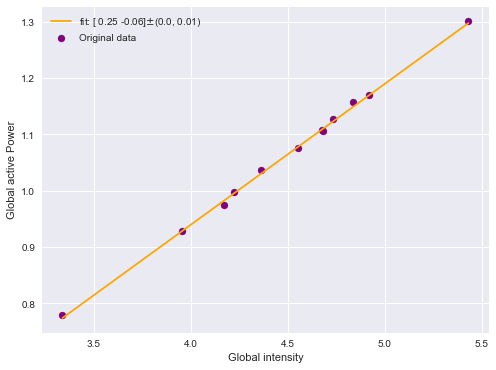

Los Coeficientes son : [ 0.25 -0.06]
Sigma_Coeficients son : [0.   0.01]


In [27]:
get_fit(G,data_mes['Global_intensity'],data_mes['Global_active_power'], "Global intensity", "Global active Power", 2)

## Función de Error
Esta función es de la forma:
$$ERROR=\sqrt{\Sigma\frac{(y-y_{fit})^2}{N}} $$

y nos muestra qué tan acertado es el ajuste de la curva en cuestion con los datos de cad arreglo. (Esta función también se toma de la que se creó en clase)

In [38]:
def get_error(G,xdata,ydata,labelx,labely,r):
    popt, pcov = curve_fit(G, xdata, ydata)
    popt, pcov = np.around(popt,r), np.around(pcov,r)
    x=np.linspace(xdata.min(),xdata.max(),100)
    E=np.sqrt(np.mean((ydata-G(xdata, *popt))**2))
    print("El error de esta curva con respecto a los datos es de ={}".format(E))
    return popt, pcov

In [39]:
get_error(G,data['Global_intensity'],data['Global_active_power'], "Global intensity", "Global active Power", 2)

El error de esta curva con respecto a los datos es de =0.05173763748702566


(array([ 0.24, -0.  ]),
 array([[ 0., -0.],
        [-0.,  0.]]))

In [40]:
get_error(G,data_día['Global_intensity'],data_día['Global_active_power'], "Global intensity", "Global active Power", 2)

El error de esta curva con respecto a los datos es de =0.022630442847155905


(array([ 0.24, -0.03]),
 array([[ 0., -0.],
        [-0.,  0.]]))

In [41]:
get_error(G,data_mes['Global_intensity'],data_mes['Global_active_power'], "Global intensity", "Global active Power", 2)

El error de esta curva con respecto a los datos es de =0.004316919789440401


(array([ 0.25, -0.06]),
 array([[ 0., -0.],
        [-0.,  0.]]))

# Conclusiones 

Al hacer el análisis numérico de las diferentes curvas y mirando el error final de cada configuración podemos ver que la que tiene un mejor ajuste es la que tiene la frecuencia de datos en meses, esto se debe a que los datos son más poquitos que en los otros dos pero a su vez los datos que ajusta pueden estar algo errados, ya que al estar ajustada sobre promedios existirá cierta data que no analizó direcatamente, aún así las tres curvas ajustan de manera expectacular con su respectivo grupo de datos.